In [7]:
#STANDARD IMPORTS
import numpy as np
import os
import matplotlib.pyplot as plt
### JUPYTER NOTEBOOK SETTINGS ########################################
#Plot all figures in full-size cells, no scroll bars
%matplotlib inline
#Disable Python Warning Output
#(NOTE: Only for production, comment out for debugging)
import warnings
warnings.filterwarnings('ignore')
### PLOTTING DEFAULTS BOILERPLATE (OPTIONAL) #########################
#SET DEFAULT FIGURE APPERANCE
import seaborn as sns #Fancy plotting package
#No Background fill, legend font scale, frame on legend
sns.set(style='whitegrid', font_scale=1.5, rc={'legend.frameon': True})
#Mark ticks with border on all four sides (overrides 'whitegrid')
sns.set_style('ticks')
#ticks point in
sns.set_style({"xtick.direction": "in","ytick.direction": "in"})
#fix invisible marker bug
sns.set_context(rc={'lines.markeredgewidth': 0.1})
#restore default matplotlib colormap
mplcolors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
'#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
sns.set_palette(mplcolors)

#Get color cycle for manual colors
colors = sns.color_palette()
#SET MATPLOTLIB DEFAULTS
#(call after seaborn, which changes some defaults)
params = {
#FONT SIZES
'axes.labelsize' : 30, #Axis Labels
'axes.titlesize' : 30, #Title
'font.size' : 28, #Textbox
'xtick.labelsize': 22, #Axis tick labels
'ytick.labelsize': 22, #Axis tick labels
'legend.fontsize': 24, #Legend font size
'font.family' : 'serif',
'font.fantasy' : 'xkcd',
'font.sans-serif': 'Helvetica',
'font.monospace' : 'Courier',
#AXIS PROPERTIES
'axes.titlepad' : 2*6.0, #title spacing from axis
'axes.grid' : True, #grid on plot
'figure.figsize' : (8,8), #square plots
'savefig.bbox' : 'tight', #reduce whitespace in saved figures
#LEGEND PROPERTIES
'legend.framealpha' : 0.5,
'legend.fancybox' : True,
'legend.frameon' : True,
'legend.numpoints' : 1,
'legend.scatterpoints' : 1,
'legend.borderpad' : 0.1,
'legend.borderaxespad' : 0.1,
'legend.handletextpad' : 0.2,
'legend.handlelength' : 1.0,
'legend.labelspacing' : 0,
}
import matplotlib
matplotlib.rcParams.update(params) #update matplotlib defaults, call after￿
### END OF BOILERPLATE ##################################################
colors = sns.color_palette() #color cycle

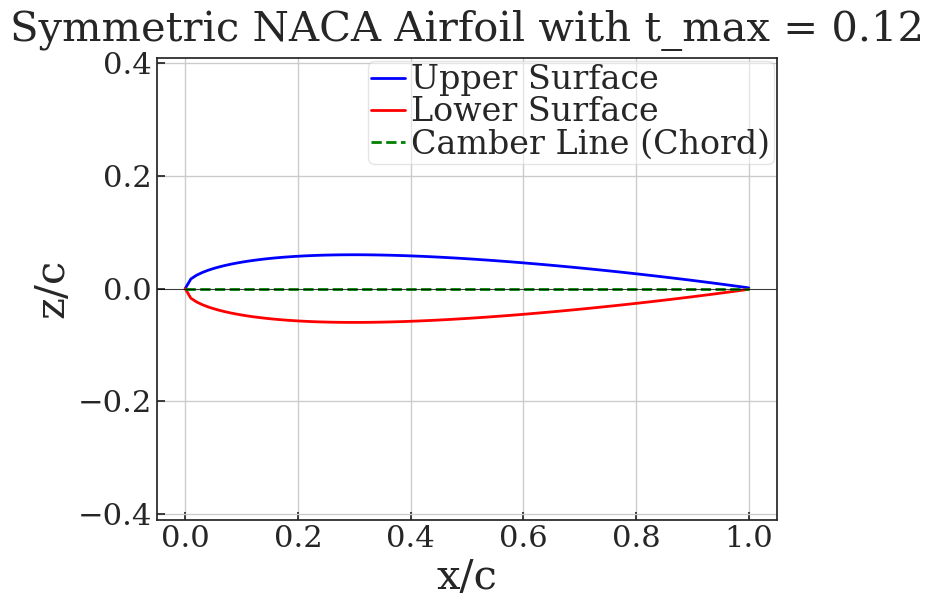

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Function to generate a symmetric NACA airfoil
def naca_symmetric_airfoil(t_max, c=1, num_points=100):
    # Create x coordinates along the chord from 0 to c (the chord length)
    x = np.linspace(0, c, num_points)
    
    # Thickness distribution (zt) using the provided NACA formula
    z_t = (t_max / 0.2) * (
        0.2969 * np.sqrt(x/c) 
        - 0.1260 * (x/c) 
        - 0.3516 * (x/c)**2 
        + 0.2843 * (x/c)**3 
        - 0.1015 * (x/c)**4
    )
    
    # Upper and lower surfaces (symmetric about the chord line)
    y_upper = z_t
    y_lower = -z_t
    
    return x, y_upper, y_lower

# Plotting the airfoil with camber line
def plot_symmetric_airfoil(t_max, c=1):
    x, y_upper, y_lower = naca_symmetric_airfoil(t_max, c)
    
    plt.figure(figsize=(8, 6))
    
    # Plot the upper and lower surfaces
    plt.plot(x, y_upper, label='Upper Surface', color='blue', linewidth=2)
    plt.plot(x, y_lower, label='Lower Surface', color='red', linewidth=2)
    
    # Plot the camber line (for symmetric airfoil, it's along the chord line y=0)
    plt.plot(x, np.zeros_like(x), label='Camber Line (Chord)', color='green', linestyle='--', linewidth=2)
    
    # Labeling and formatting
    plt.axhline(0, color='black',linewidth=0.5) # Chord line
    plt.title(f'Symmetric NACA Airfoil with t_max = {t_max}')
    plt.xlabel('x/c')
    plt.ylabel('z/c')
    plt.legend()
    plt.axis('equal')  # Ensures equal scaling for both axes
    plt.grid(True)
    plt.show()

# Example usage: Plot a NACA 0012 airfoil (12% thickness)
plot_symmetric_airfoil(t_max=0.12)


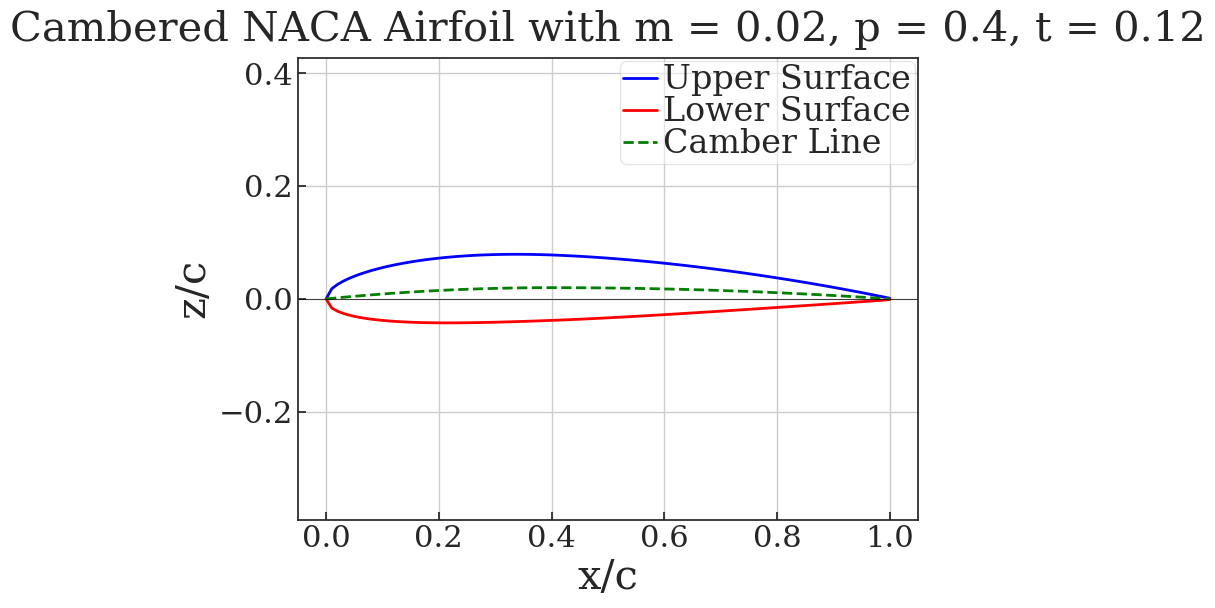

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Function to generate a cambered NACA airfoil
def naca_cambered_airfoil(m, p, t, c=1, num_points=100):
    # Create x coordinates along the chord from 0 to c
    x = np.linspace(0, c, num_points)
    
    # Initialize camber line array
    z_c = np.zeros_like(x)
    
    # Camber line equation (for both regions)
    for i in range(num_points):
        if x[i] <= p * c:
            z_c[i] = (m / p**2) * (2 * p * (x[i]/c) - (x[i]/c)**2)
        else:
            z_c[i] = (m / (1 - p)**2) * ((1 - 2 * p) + 2 * p * (x[i]/c) - (x[i]/c)**2)
    
    # Thickness distribution (same as in 1.1)
    z_t = (t / 0.2) * (
        0.2969 * np.sqrt(x/c) 
        - 0.1260 * (x/c) 
        - 0.3516 * (x/c)**2 
        + 0.2843 * (x/c)**3 
        - 0.1015 * (x/c)**4
    )
    
    # Upper and lower surfaces
    y_upper = z_c + z_t
    y_lower = z_c - z_t
    
    return x, y_upper, y_lower, z_c

# Plotting function for cambered airfoil
def plot_cambered_airfoil(m, p, t, c=1):
    x, y_upper, y_lower, z_c = naca_cambered_airfoil(m, p, t, c)
    
    plt.figure(figsize=(8, 6))
    
    # Plot the upper and lower surfaces
    plt.plot(x, y_upper, label='Upper Surface', color='blue', linewidth=2)
    plt.plot(x, y_lower, label='Lower Surface', color='red', linewidth=2)
    
    # Plot the camber line
    plt.plot(x, z_c, label='Camber Line', color='green', linestyle='--', linewidth=2)
    
    # Labeling and formatting
    plt.axhline(0, color='black', linewidth=0.5)  # Chord line
    plt.title(f'Cambered NACA Airfoil with m = {m}, p = {p}, t = {t}')
    plt.xlabel('x/c')
    plt.ylabel('z/c')
    plt.legend()
    plt.axis('equal')  # Ensures equal scaling for both axes
    plt.grid(True)
    plt.show()

# Example usage: Plot a cambered NACA 2412 airfoil (m = 0.02, p = 0.4, t = 0.12)
plot_cambered_airfoil(m=0.02, p=0.4, t=0.12)


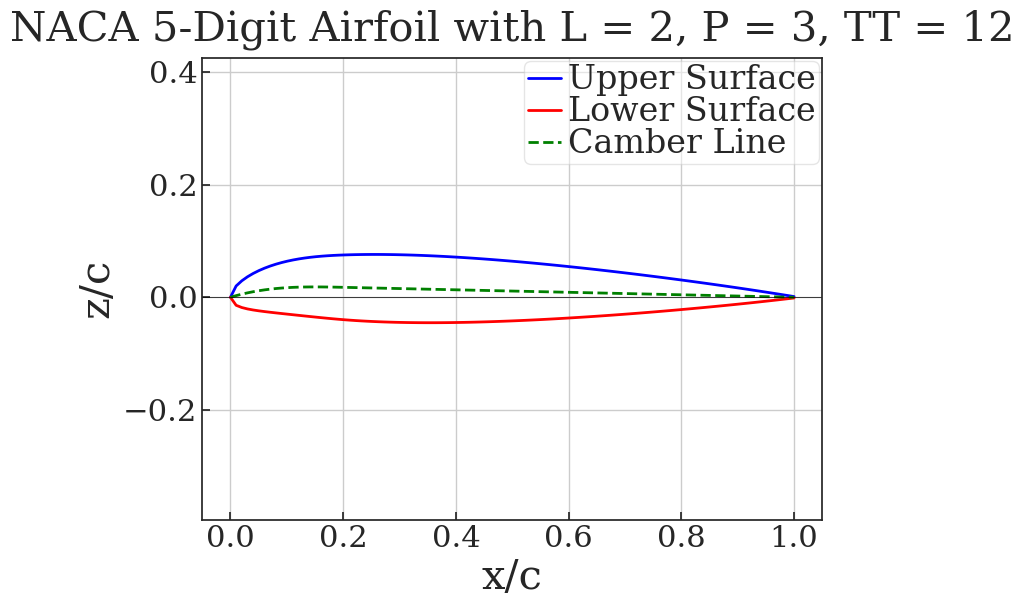

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# NACA Code Input (NACA LPSTT)
n1 = 2  # L, first digit (Design lift coefficient in multiples of 0.15)
n2 = 3  # P, second digit (Location of max camber in multiples of 5%)
n3 = 0  # S, third digit (0 for simple camber, 1 for reflex camber; ignored here since we assume simple camber)
n4 = 1  # T, first thickness digit
n5 = 2  # T, second thickness digit

# Extract values for L, P, TT
L = n1  # Design lift coefficient (in multiples of 0.15, e.g. 2 means 0.30)
P = n2  # Location of max camber (e.g., 3 means 15% of chord)
TT = n4 * 10 + n5  # Thickness as percentage of chord (e.g., 12% means TT = 12)

# Dictionary to hold r and k1 values for different P
r_values = {1: 0.058, 2: 0.126, 3: 0.2025, 4: 0.29, 5: 0.391}
k1_values = {1: 361.4, 2: 51.64, 3: 15.957, 4: 6.643, 5: 3.23}

# Function to generate a NACA 5-digit airfoil
def naca_5_digit_airfoil(L, P, TT, c=1, num_points=100):
    # Get r and k1 based on P
    r = r_values[P]
    k1 = k1_values[P]
    
    # Create x coordinates along the chord from 0 to c
    x = np.linspace(0, c, num_points)
    
    # Initialize camber line array
    z_c = np.zeros_like(x)
    
    # Camber line equation for both regions
    for i in range(num_points):
        if x[i] < r:
            z_c[i] = (k1 / 6) * (x[i]**3 - 3 * r * x[i]**2 + r**2 * (3 - r) * x[i])
        else:
            z_c[i] = (k1 * r**3 / 6) * (1 - x[i])
    
    # Scale the camber line by L/2 (L is the design lift coefficient)
    z_c = (L / 2) * z_c
    
    # Thickness distribution (same formula as the 4-digit airfoil)
    t = TT / 100  # Convert thickness percentage to a decimal
    z_t = (t / 0.2) * (
        0.2969 * np.sqrt(x/c) 
        - 0.1260 * (x/c) 
        - 0.3516 * (x/c)**2 
        + 0.2843 * (x/c)**3 
        - 0.1015 * (x/c)**4
    )
    
    # Upper and lower surfaces
    y_upper = z_c + z_t
    y_lower = z_c - z_t
    
    return x, y_upper, y_lower, z_c

# Plotting function for NACA 5-digit airfoil
def plot_naca_5_digit_airfoil(L, P, TT, c=1):
    x, y_upper, y_lower, z_c = naca_5_digit_airfoil(L, P, TT, c)
    
    plt.figure(figsize=(8, 6))
    
    # Plot the upper and lower surfaces
    plt.plot(x, y_upper, label='Upper Surface', color='blue', linewidth=2)
    plt.plot(x, y_lower, label='Lower Surface', color='red', linewidth=2)
    
    # Plot the camber line
    plt.plot(x, z_c, label='Camber Line', color='green', linestyle='--', linewidth=2)
    
    # Labeling and formatting
    plt.axhline(0, color='black', linewidth=0.5)  # Chord line
    plt.title(f'NACA 5-Digit Airfoil with L = {L}, P = {P}, TT = {TT}')
    plt.xlabel('x/c')
    plt.ylabel('z/c')
    plt.legend()
    plt.axis('equal')  # Ensures equal scaling for both axes
    plt.grid(True)
    plt.show()

# Plot the NACA 5-digit airfoil
plot_naca_5_digit_airfoil(L, P, TT)


